In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

(564, 92)
Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 's

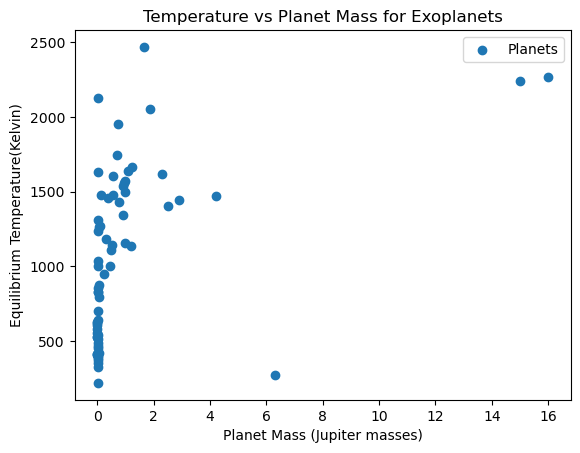

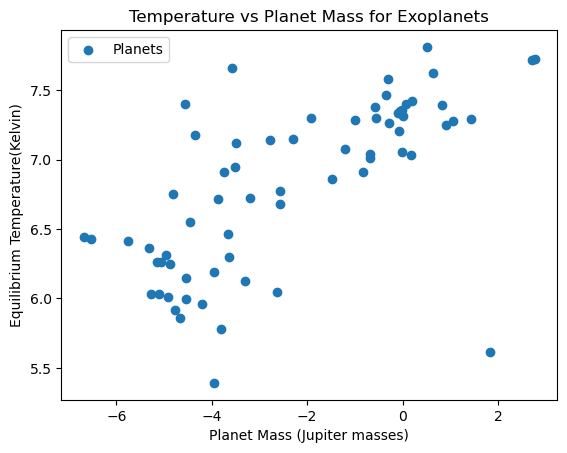

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 563, dtype: object


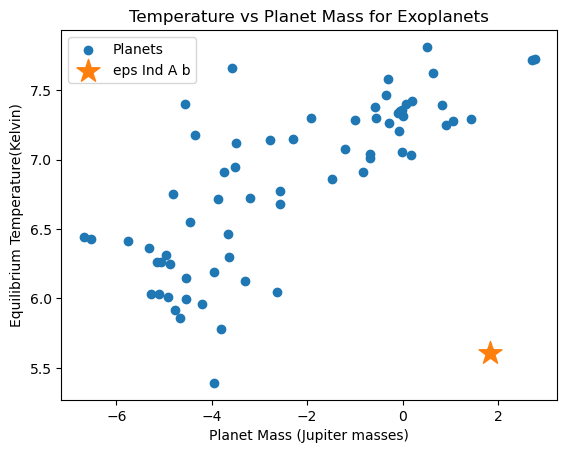

In [43]:
df = pd.read_csv("exoplanet_data.csv", comment = "#")
print(df.shape)
#Dataframe with 564 rows and 92 columns
print(df.columns)
#pl_orbeccenlim, pl_insol, pl_insolerr1, st_logg, sy_kmag
#Planet name is pl_name, "Planet name most commonly used in the literature" names the planet
#Host name is hostname, "Stellar name most commonly used in the literature" name of the star
#Method of discovery is discoverymethod, "Method by which the planet was first identified", how did they discover it
#Spectral type is st_spectype, "Classification of the star based on their spectral characteristics following the Morgan-Keenan system" What kind of star is it
#Equilibrium temperature is pl_eqt, "The equilibrium temperature of the planet as modeled by a black body heated only by its host star, or for
#directly imaged planets, the effective temperature of the planet required to match the measured luminosity if the planet were a black body" Mathematical estimate for average temperature
#Planet mass in Jupiters is pl_bmassj, "Amount of matter contained in the planet, measured in units of masses of Jupiter" how many Jupiters does it weigh
df2 = df[['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt', 'pl_bmassj']].dropna()
print(df2.shape)
#67x6 dataframe, 67 rows and 6 columns.
df2.head(5)
df2.tail(5)
print(df2.columns)
print(df2['discoverymethod'].value_counts())
#3 types of discovery methods, transit(most, 52), radial velocity(13), imaging(least, 2).
#Transit is measuring differences in brightness of a star as it is eclipsed.
#Radial velocity is watching the effect of a star's position as the planet's gravity affects it.
#Imaging is finding a planet ghrough phototgraphing it directly.

plt.plot(figsize = (8,6))
plt.scatter(df2['pl_bmassj'], df2['pl_eqt'], label = "Planets")
plt.xlabel("Planet Mass (Jupiter masses)")
plt.ylabel("Equilibrium Temperature(Kelvin)")
plt.title("Temperature vs Planet Mass for Exoplanets")
plt.legend()
plt.show()

plt.plot(figsize = (8,6))
plt.scatter(np.log(df2['pl_bmassj']), np.log(df2['pl_eqt']), label = "Planets")
plt.xlabel("Planet Mass (Jupiter masses)")
plt.ylabel("Equilibrium Temperature(Kelvin)")
plt.title("Temperature vs Planet Mass for Exoplanets")
plt.legend()
plt.show()

#Exoplanets found by the imaging method are more likely to be smaller than Jupiter.
mintempbutlarge = 100000
minindex = 0
for index, row in df2.iterrows():
    if row["pl_bmassj"] > 5:
        if row["pl_eqt"] < mintempbutlarge:
            mintempbutlarge = row["pl_eqt"]
            minindex = index
print(df2.loc[minindex])

#eps Ind A b is the smallest planet.
#index at 563, T eq = 273 K, mass = 6.31 Jupiters, orbiting a K5 V (Not a sun-like star[g type])

plt.plot(figsize = (8,6))
plt.scatter(np.log(df2['pl_bmassj']), np.log(df2['pl_eqt']), label = "Planets")
plt.xlabel("Planet Mass (Jupiter masses)")
plt.ylabel("Equilibrium Temperature(Kelvin)")
plt.title("Temperature vs Planet Mass for Exoplanets")
plt.scatter(np.log(6.31), np.log(273), s = 300, label = "eps Ind A b", marker = "*")
plt.legend()
plt.show()

#Title: A temperate super-Jupiter imaged with JWST in the mid-infrared
#Abstract: Radial velocity measurements indicated a large star orbiting a nearby star, and it was measured to have high brightness/low temperatures. This is a new range for thermal models, but fits current models.
#Answer matches? Our answer matches the exoplanet.
#What's special about the planet: The planet is very large and still with an equilibrium temperature around room temperature, a previously unfound range.
#Do mass/equilibrium temp match? 275K and 6.31 Jupiter masses, which matches our answers.